In [1]:
x=5
y=3.14

numbers =[1,2,3,4] # list

config ={k:'0.05',p:'1'} #dictionary

def rosenbrook(x,y):
    return (1-x)**2+100*(y-x**2)**2

result = rosenbrook(0.0,0.0)

NameError: name 'k' is not defined

In [5]:
def rosenbrook(x,y):
    return (1-x)**2+(100*(y-x**2)**2)

print(rosenbrook(2.0,5.0))


101.0


In [8]:
for i in range(10):
    print(f"Iteration{i+1}")

Iteration1
Iteration2
Iteration3
Iteration4
Iteration5
Iteration6
Iteration7
Iteration8
Iteration9
Iteration10


In [10]:
import numpy as np

x = np.array([1,2,3])

y=x+10

A= np.array([[1,2],[3,4]])

B= np.array([[5,6],[7,8]])

C = A@B #matrix multiplication

det= np.linalg.det(A)

norm= np.linalg.norm(x)

print(C)
print(det)
print(norm)

[[19 22]
 [43 50]]
-2.0000000000000004
3.7416573867739413


In [15]:
#creating tensors 
import torch
import numpy as np

x=torch.tensor([1.0,2.0,3.0])

y=torch.zeros(3,3)
z=torch.randn(2,4)
tensor= torch.from_numpy(np.array([1,2,3]))

x1= torch.tensor(2.0, requires_grad= True)
y1= x1**2+3*x1+1
y1.backward() #computes gradients
print(x1.grad) #grad access the gradients
b=x*2
print(b)


tensor(7.)
tensor([2., 4., 6.])


In [18]:
import torch

x = torch.tensor([1.0,2.0], requires_grad= True)

#rosenbrock function
f = (1-x[0])**2 + 100*(x[1]-x[0]**2)**2

f.backward()

print(x.grad)

x.grad.zero_() #resets the gradients

tensor([-400.,  200.])


tensor([0., 0.])

In [25]:
import torch

x= torch.tensor([0.0,0.0], requires_grad= True)

for i in range(1000):
    f = (1-x[0])**2 + 100*(x[1]-x[0]**2)**2
    f.backward()
    with torch.no_grad(): #for parameter update
        x = -0.001 + x.grad #autogradient computation, with learning rate 0.001
        print(f"for iteration {i}, the gradient of x is {x.grad}")
        x.grad.zero_()



for iteration 0, the gradient of x is None


AttributeError: 'NoneType' object has no attribute 'zero_'

In [24]:
import torch

x = torch.tensor([0.0, 0.0], requires_grad=True)
learning_rate = 0.001

for i in range(3):
    f = (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2
    f.backward()
    print(f"Iteration {i}, x.grad:", x.grad)
    with torch.no_grad():
        x -= learning_rate * x.grad
        print(f"Iteration {i} after update, x.grad:", x.grad)
        x.grad.zero_()

Iteration 0, x.grad: tensor([-2.,  0.])
Iteration 0 after update, x.grad: tensor([-2.,  0.])
Iteration 1, x.grad: tensor([-1.9960e+00, -8.0000e-04])
Iteration 1 after update, x.grad: tensor([-1.9960e+00, -8.0000e-04])
Iteration 2, x.grad: tensor([-1.9920, -0.0030])
Iteration 2 after update, x.grad: tensor([-1.9920, -0.0030])


In [28]:
# Assignment 1: Solving the Rosenbrock function
# Required to run CMA-ES and L-BFGS optimization
#FD error bs step size
#Use central differencing

import torch

def rosenbrock(x):
    return (1-x[0])**2 + 100*(x[1]-x[0]**2)**2

x = torch.tensor([0.0,0.0], requires_grad= True)
f= rosenbrock(x)
f.backward()
autograd_grad = x.grad.clone()
h = 0.001
central_diff_grad = torch.zeros(2)

with torch.no_grad():
    x_plus_h = x.clone()
    x_plus_h[0] += h
    x_minus_h = x.clone()
    x_minus_h[0] -= h
    central_diff_grad[0] = (rosenbrock(x_plus_h)- rosenbrock(x_minus_h)) /(2*h)

    y_plus_h = x.clone()
    y_plus_h[0] += h
    y_minus_h = x.clone()
    y_minus_h[0] -= h
    central_diff_grad[0] = (rosenbrock(y_plus_h)- rosenbrock(y_minus_h)) /(2*h)

print("Auto_grad:", autograd_grad)
print("Central diff:", central_diff_grad)

Auto_grad: tensor([-2.,  0.])
Central diff: tensor([-2.0000,  0.0000])


using device: cpu
Rosenbrock function optimization
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1      6 1.549530913810138e+01 1.0e+00 3.89e-01  3e-01  4e-01 0:00.0
    2     12 3.126281330895184e+00 1.2e+00 3.48e-01  2e-01  4e-01 0:00.0
    3     18 8.302402654391664e-01 1.5e+00 3.91e-01  2e-01  5e-01 0:00.0
  100    600 1.845583233256406e-11 4.8e+01 3.39e-03  1e-05  3e-05 0:00.1
  125    750 1.942455362249317e-15 4.3e+01 9.77e-05  3e-08  7e-08 0:00.1
termination on {'tolfun': 1e-11}
final/bestever f-value = 1.942455e-15 6.749308e-16 after 750/742 evaluations
incumbent solution: [1.00000002, 1.00000005]
std deviations: [3.36756199e-08, 6.93479656e-08]
Evaluration functions:750
Time:0.7579026222229004
Solution:x=1.0000000240358125, y=1.0000000490575793
Min value:6.749307624950268e-16
Evaluation:143
Time taken:0.22270655632019043
Solution of x:1.0000001192092896
Min value:1.566888840898173e-10
error in df/dx:0.0
Error in df/dy:0.0


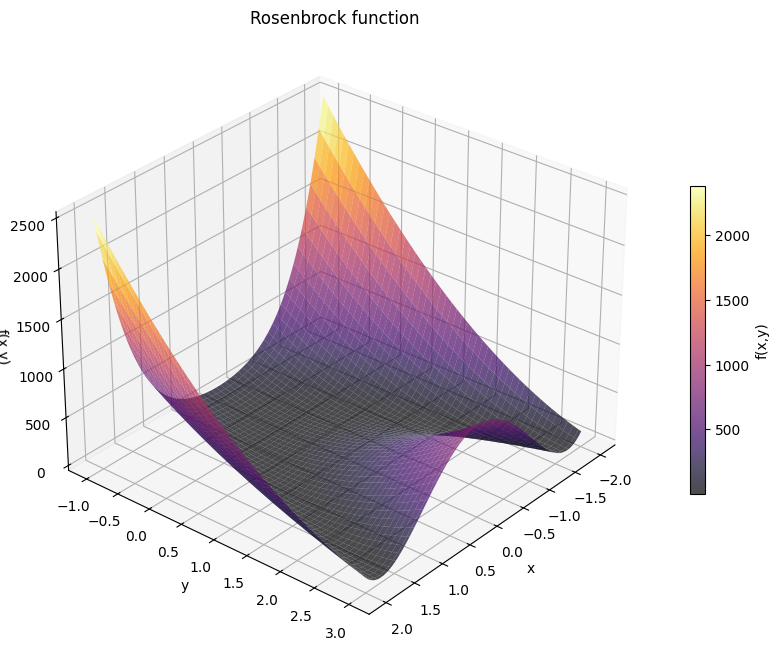

In [24]:
#rosenbrock function f(x,y) = (1-x)^2 + 100*(y-x^2)^2

#global minima at 1,1 

import numpy as np
import matplotlib.pyplot as plt
import torch
from mpl_toolkits.mplot3d import Axes3D
import time
from scipy.optimize import minimize
from cma import CMAEvolutionStrategy
import warnings

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")


def rosenbrock_numpy(x):
    return (1-x[0])**2+ 100*(x[1]-x[0]**2)**2

def rosenbrock_torch(x):
    return (1-x[0])**2+ 100*(x[1]-x[0]**2)**2

def rosenbrock_plotting(x,y):
    return (1-x)**2 + 100 *(y- x**2)**2

def rosenbrock_analytical(x,y):
    #f = (1-x)^2 + 100*(y-x^2)^2
    #df/ax =  -2(1-x) + 100*2*(y-x2)*2x
    #df/dy = 2*100(y-x2)*1
    dfdx = -2*(1-x)-4*100*x*(y-x**2)
    dfdy= 2*100*(y-x**2)
    return dfdx, dfdy

# ====================================================== #
# Section 2 : Visulize                                   #
# ====================================================== #

print("=" * 60)
print ("Rosenbrock function optimization")
print("=" * 60)

x_range = np.linspace(-2,2,100)
y_range = np.linspace(-1,3,100)
X, Y = np.meshgrid(x_range, y_range)
Z= rosenbrock_plotting(X, Y)

fig = plt.figure(figsize=(12,8))
ax= fig.add_subplot(111, projection = '3d')
surface = ax.plot_surface(X,Y,Z, cmap='inferno', alpha=0.7)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Rosenbrock function')
ax.view_init(elev=30, azim =40)
fig.colorbar(surface, shrink=0.5, label='f(x,y)')
plt.show


# ======================================================= #
# Section 3: Gradient free optimization CMA-ES            #
# ======================================================= #

x0 = np.zeros(2)
def objective_fun(x):
    return rosenbrock_numpy(x)

start_time = time.time()
es= CMAEvolutionStrategy(x0, 0.5, {'bounds':[[-2,-2],[2,2]],'verbose':-1})
es.optimize(objective_fun, maxfun=10000)
cmas_time = time.time()- start_time

results_cmaes = es.result
print(f"Evaluration functions:{results_cmaes.evaluations}")
print(f"Time:{cmas_time}")
print(f"Solution:x={results_cmaes.xbest[0]}, y={results_cmaes.xbest[1]}")
print(f"Min value:{results_cmaes.fbest}")


# ================================================= #
# Gradient based optimization                       #
# ================================================= #

x = torch.tensor([0.0,0.0], requires_grad= True, device =device)

optimizer= torch.optim.LBFGS(
    [x],
    max_iter=100,
    tolerance_grad= 1e-7,
    tolerance_change=1e-9
)

num_evals = 0

def closure():
    global num_evals
    num_evals += 1
    optimizer.zero_grad()
    loss = rosenbrock_torch(x)
    loss.backward()
    return loss

start_time = time.time()
for i in range(100):
    loss = optimizer.step(closure)
    if x.grad is not None and torch.norm(x.grad) < 1e-7:
        break

lbfgs_time = time.time() - start_time

print(f"Evaluation:{num_evals}")
print(f"Time taken:{lbfgs_time}")
print(f"Solution of x:{x[0]}")
print(f"Min value:{rosenbrock_torch(x)}")

# ========================================== #
#        Finite difference gradient Analysis #
# ========================================== #

eval_point =[0.5,0.5]
analytical_grad_x, analytical_grad_y = rosenbrock_analytical(eval_point[0], eval_point[1])

x_ad = torch.tensor(eval_point, requires_grad=True)
f_ad = rosenbrock_torch(x_ad)
f_ad.backward()
ad_grad_x = x_ad.grad[0].item()
ad_grad_y = x_ad.grad[1].item()

error_x = abs(analytical_grad_x - ad_grad_x)
error_y = abs(analytical_grad_y- ad_grad_y)
print(f"error in df/dx:{error_x}")
print(f"Error in df/dy:{error_y}")

exact_gradient = ad_grad_x


<function matplotlib.pyplot.show(close=None, block=None)>

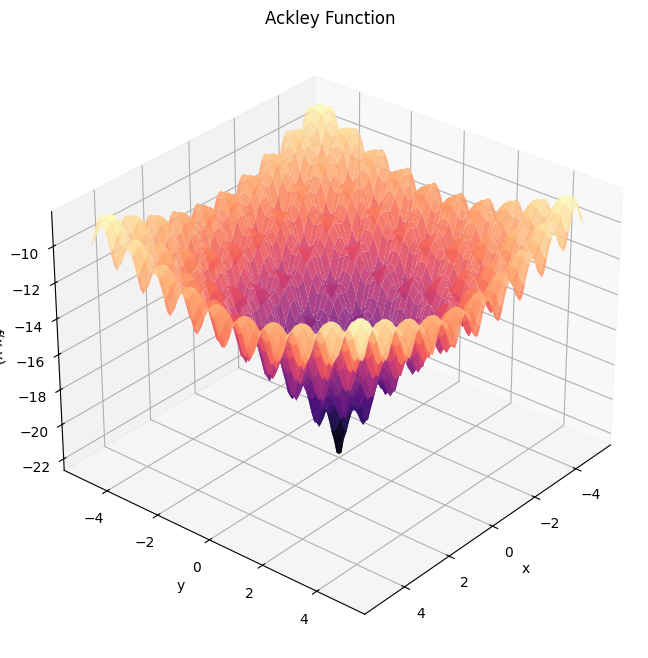

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
from scipy.optimize import minimize

def Ackely(x,y):
    term1 =  -20 * np.exp(-0.2*np.sqrt(0.5*(x**2 + y**2)))
    term2 = -np.exp(0.5*(np.cos(2.*np.pi*x)+np.cos(2*np.pi*y)))
    return term1 + term2

fig = plt.figure(figsize=(12,8))
x= np.linspace(-5,5,100)
y= np.linspace(-5,5,100)
X,Y = np.meshgrid(x,y)
Z= Ackely(X,Y)

ax= fig.add_subplot(111, projection='3d')
surf= ax.plot_surface(X,Y,Z,cmap='magma', alpha=0.9)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Ackley Function')
ax.view_init(elev=30, azim =40)
fig.colorbar(surface, shrink=0.5, label='f(x,y)')
plt.show


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize

slsqp_history=[] #gradient based optimization method
nm_history=[] #nelyer mead gradient free optimization method

def rosenbrock_slsqp(x):
    slsqp_history.append(x.copy())
    return (1-x[0])**2+100*(x[1]-x[0]**2)**2

def rosenbrock_nm(x):
    nm_history.append(x.copy())
    return (1-x[0])**2+100*(x[1]-x[0]**2)**2

start_point = np.array([5.0,2.0])

results_slsqp = minimize(rosenbrock_slsqp, start_point, method='SLSQP')
results_nm = minimize(rosenbrock_nm, start_point, method='Nelder-Mead')

slsqp_pts= np.array(slsqp_history)
nm_pts = np.array(nm_history)

x1= np.linspace(-5,5,100)
x2=np.linspace(-5,5,100)

X1,X2 = np.meshgrid(x1, x2)
Z= (1-X1)**2 + 100*(X2 - X1**2)**2


Complex step differentialtion: Isentropic Vortex
1e-06           12.3949994314
1e-10           12.3949994310
1e-20           12.3949994310
1e-30           12.3949994310
1e-50           12.3949994310
1e-100          12.3949994310
1e-02           12.3485987993
1e-04           12.3949947828
1e-06           12.3949994305
1e-08           12.3949994268
1e-10           12.3949994713
1e-12           12.3949739361
error:9.14e+01


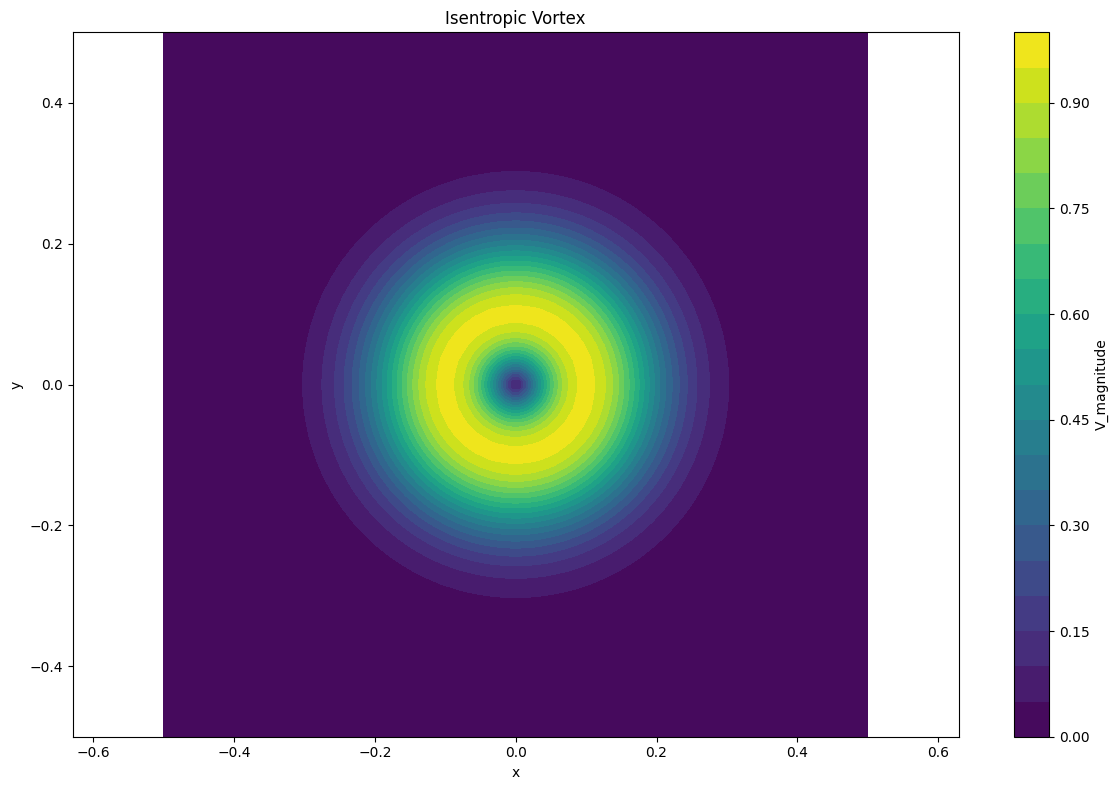

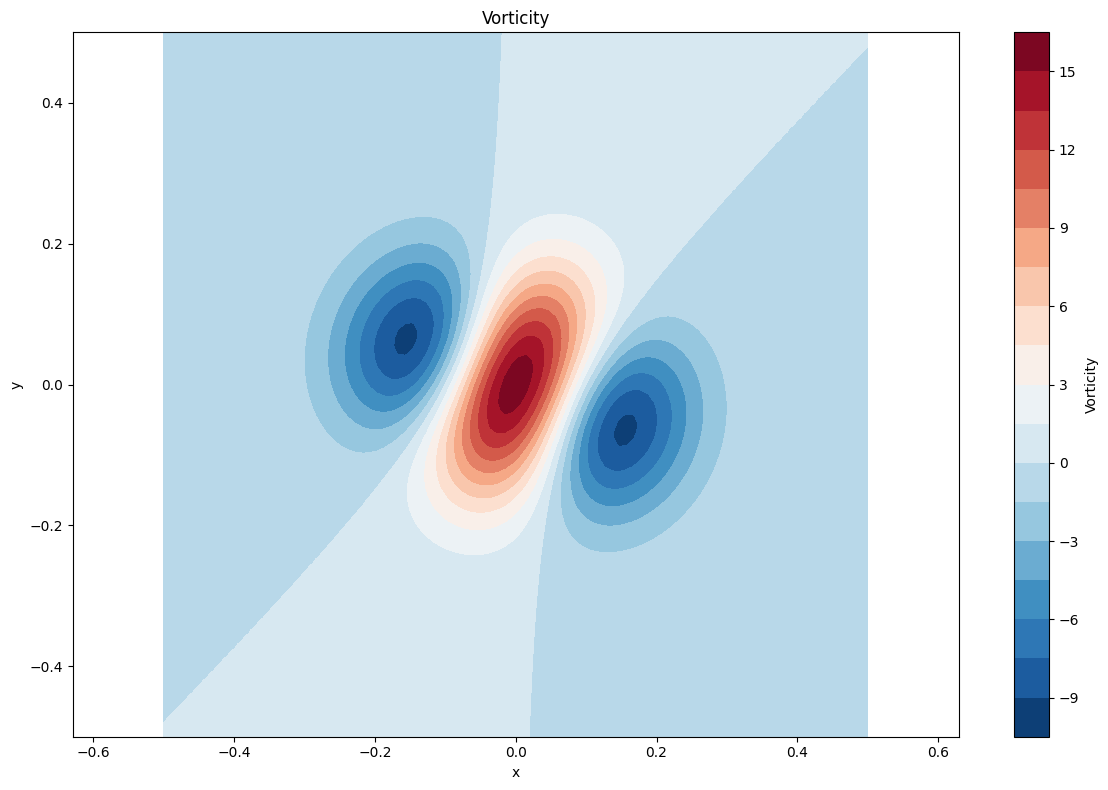

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple
#vortex veloctiy field : veloctiy potential = gamma/ 2*pi*R
#f(x + ih) = f(x) + ih f'(x) - h2f''(x)
#Im(f(x+ih)) = hf'(x) +0(h3)
# f'(x) = Im(f(x+ih))/h

#u',v' = gamma/ 2piR * exp(1 -(r/R)**2/2) *(y0-y, x-x0)
def velocity_perturbations(x,y, gamma, x0, y0, R):
    dx= x-x0
    dy= y-y0
    r_sq = dx**2 + dy**2
    R_sq = R**2

    exp_term= np.exp(-r_sq/R_sq/2)

    factor = gamma/ (2*np.pi*R_sq)
    u_prime = -factor * dy *exp_term
    v_prime = factor *dx* exp_term

    return u_prime, v_prime

def vorticity_complex_step(x,y,gamma, x0, y0, R, epsilon= 1e-30):
    """
    Vorticity is omega = dv/dx - du/dy
    dv/dx = Im[v(x+i*eps, y)]/eps
    du/dy = Im[u(x , y+i*eps)]/eps 
    eps: complex step size

    """
    x_complex = x.astype(complex)
    y_complex = y.astype(complex)

    #compute dv/dx
    x_pertubed = x_complex + 1j*epsilon
    _, v_at_x_plus_ih = velocity_perturbations(x_pertubed, y_complex, gamma, x0, y0, R)
    dv_dx= np.imag(v_at_x_plus_ih)/epsilon

    y_pertubed = y_complex + 1j*epsilon
    _, u_at_y_plus_ih = velocity_perturbations(x_complex, y_pertubed, gamma, x0, y0, R)
    du_dy= np.imag(u_at_y_plus_ih)/epsilon

    vorticity = dv_dx - du_dy
    return np.real(vorticity)

def vorticity_finite_difference(x,y,gamma, x0,y0, r, h=1e-6):
    """
    dv/dx= v(x+h) - v(x-h)/2h
    du/dy = u(y+h) - u(y-h)/2h

    """
    _, v_plus = velocity_perturbations(x+h, y, gamma, x0, y0, R)
    _, v_minus = velocity_perturbations(x-h, y, gamma, x0, y0, R)
    dv_dx = (v_plus - v_minus) /(2*h)

    _, u_plus = velocity_perturbations(x, y+h, gamma, x0, y0, R)
    _, u_minus = velocity_perturbations(x, y-h, gamma, x0, y0, R)
    du_dy = (u_plus - u_minus) /(2*h)

    vorticity = dv_dx - du_dy

    return vorticity


print('='*60)
print('Complex step differentialtion: Isentropic Vortex')
print('=' * 60)

gamma = 1.0
x0, y0 = 0.0, 0.0
R =0.1
grid_size = 100

x_1d =  np.linspace(-0.5,0.5,grid_size)
y_1d = np.linspace(-0.5, 0.5, grid_size)
X,Y = np.meshgrid(x_1d, y_1d)

U, V = velocity_perturbations(X,Y, gamma, x0, y0, R)
velocity_magnitude = np.sqrt(U**2 + V**2)

plt.figure(figsize=(12,8))
plt.contourf(X,Y, velocity_magnitude, levels= 20, cmap='viridis')
plt.colorbar(label='V_magnitude')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Isentropic Vortex')
plt.axis('equal')
plt.tight_layout()
plt.show

#vorticity plot

vorticity_cs = vorticity_complex_step(X,Y,gamma, x0, y0, R, epsilon= 1e-30)
plt.figure(figsize=(12,8))
plt.contourf(X,Y, vorticity_cs, levels= 20, cmap='RdBu_r')
plt.colorbar(label='Vorticity')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Vorticity')
plt.axis('equal')
plt.tight_layout()
plt.show

#Compare Complex and finite difference

test_x, test_y = 0.05, 0.05

for eps in [1e-6, 1e-10, 1e-20, 1e-30, 1e-50, 1e-100]:
    vort = vorticity_complex_step(np.array([test_x]), np.array([test_y]), gamma, x0, y0, R, epsilon=eps)[0]
    print(f"{eps:<15.0e} {vort:.10f}")

for h in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]:
    vort = vorticity_finite_difference(np.array([test_x]), np.array([test_y]), gamma, x0, y0, R, h=h)[0]
    print(f"{h:<15.0e} {vort:.10f}")


## Vorticity analytical ###

def vorticity_analytical(x,y,gamma, x0,y0,R):
    dx= x-x0
    dy=y-y0
    r_sq =dx**2 +dy**2
    R_sq = R**2

    term1 = gamma / (2*np.pi*R_sq)
    term2 = 2 -(r_sq**2 / R_sq)
    term3 = np.exp(1 -(r_sq**2 / R_sq) / 2)

    vorticity_ana = term1*term2*term3
    return vorticity_ana

vorticity_analytical = vorticity_analytical(X,Y, gamma, x0, y0, R)
error = np.abs(vorticity_cs - vorticity_analytical)
print(f"error:{np.max(error):.2e}")

Using Random Initilization
Epoch100: loss=0.078138
Epoch200: loss=0.010608
Epoch300: loss=0.003150
Epoch400: loss=0.001324
Epoch500: loss=0.000644
using xavier initilization
Epoch100: loss=0.077983
Epoch200: loss=0.002996
Epoch300: loss=0.007453
Epoch400: loss=0.000581
Epoch500: loss=0.000812


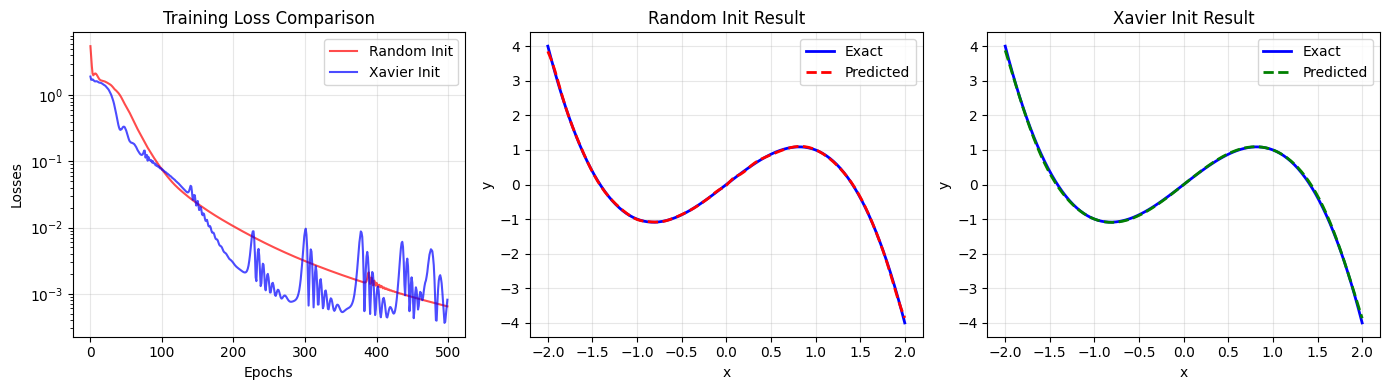


RESULTS SUMMARY
Random Init - Final Loss: 0.000644
Xavier Init - Final Loss: 0.000812

Xavier initialization typically trains better!
Plot saved as 'exercise1_results.png'


In [20]:
##Day 2: Structure n Intepretation of Deep Neural Networks
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

x_data = torch.linspace(-2,2,101).reshape(-1,1)
y_data= 2*x_data - x_data**3

# working on y= 2x- x^3

class SimpleNetwork(nn.Module):
    def __init__(self, use_xavier = False):
        super().__init__()
        
        self.layer1= nn.Linear(1,10)
        self.layer2 = nn.Linear(10,20)
        self.layer3 = nn.Linear(20,10)
        self.layer4 = nn.Linear(10,1)

        if  use_xavier:
            for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
            print("using xavier initilization")
        else:
            for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
                nn.init.normal_(layer.weight, mean=0, std= 1.0)
                nn.init.zeros_(layer.bias)
            print("Using Random Initilization")

    def forward(self,x):
        x= torch.tanh(self.layer1(x))
        x= torch.tanh(self.layer2(x))
        x= torch.tanh(self.layer3(x))
        x= self.layer4(x)
        return x


## Training 

def train(model, epochs=500, lr=0.01):
    optimizer= optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses=[]

    for epoch in range(epochs):
        #Forward pass
        prediction = model(x_data)
        loss= loss_fn(prediction, y_data)

        #backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #record loss
        losses.append(loss.item())

        #progress
        if (epoch + 1) % 100 == 0:
            print(f"Epoch{epoch+1}: loss={loss.item():.6f}")

    return losses

#train both models

model_random = SimpleNetwork(use_xavier=False)
losses_random = train(model_random, epochs= 500)

model_xavier= SimpleNetwork(use_xavier=True)
losses_xavier = train(model_xavier, epochs= 500)

fig, axes = plt.subplots(1,3,figsize=(14,4))

axes[0].plot(losses_random,'r-',label='Random Init', alpha =0.7)
axes[0].plot(losses_xavier,'b-',label='Xavier Init', alpha =0.7)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Losses')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

with torch.no_grad():
    pred_random= model_random(x_data).numpy()
axes[1].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[1].plot(x_data.numpy(), pred_random, 'r--', linewidth=2, label='Predicted')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Random Init Result')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

with torch.no_grad():
    pred_xavier = model_xavier(x_data).numpy()
axes[2].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[2].plot(x_data.numpy(), pred_xavier, 'g--', linewidth=2, label='Predicted')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Xavier Init Result')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"Random Init - Final Loss: {losses_random[-1]:.6f}")
print(f"Xavier Init - Final Loss: {losses_xavier[-1]:.6f}")
print(f"\nXavier initialization typically trains better!")
print("Plot saved as 'exercise1_results.png'")
                
                


Data created: 101 points from x=-2 to x=2
Target function: y = 2x - x^3


Training Model 1: Random Initialization
Using random initialization (std=1.0)
  Epoch 100: Loss = 0.005997
  Epoch 200: Loss = 0.000860
  Epoch 300: Loss = 0.000914
  Epoch 400: Loss = 0.001298
  Epoch 500: Loss = 0.000255

Training Model 2: Xavier Initialization
Using Xavier initialization
  Epoch 100: Loss = 0.061529
  Epoch 200: Loss = 0.011499
  Epoch 300: Loss = 0.002046
  Epoch 400: Loss = 0.040811
  Epoch 500: Loss = 0.000602


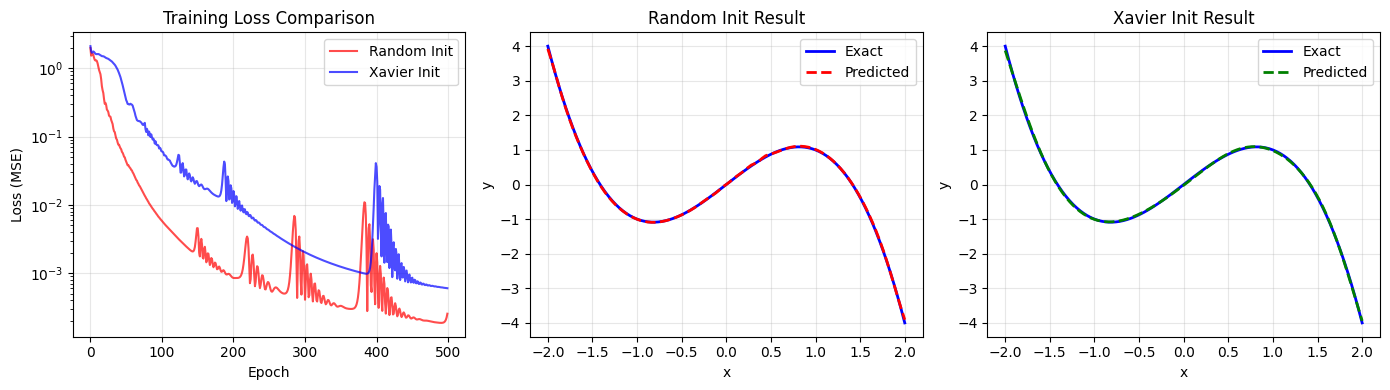


RESULTS SUMMARY
Random Init - Final Loss: 0.000255
Xavier Init - Final Loss: 0.000602

Xavier initialization typically trains better!
Plot saved as 'exercise1_results.png'


In [12]:
"""
Exercise 1: Effect of Weight Initialization
============================================
Compare random initialization vs Xavier initialization

Run: python exercise1_init.py
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================
# Step 1: Create the training data
# ============================================
# We want to learn: y = 2x - x^3
x_data = torch.linspace(-2, 2, 101).reshape(-1, 1)  # 101 points
y_data = 2 * x_data - x_data ** 3

print("Data created: 101 points from x=-2 to x=2")
print(f"Target function: y = 2x - x^3\n")


# ============================================
# Step 2: Define the neural network
# ============================================
class SimpleNetwork(nn.Module):
    """A simple 4-layer network: 1 -> 10 -> 20 -> 10 -> 1"""

    def __init__(self, use_xavier=False):
        super().__init__()

        # Define layers
        self.layer1 = nn.Linear(1, 10)
        self.layer2 = nn.Linear(10, 20)
        self.layer3 = nn.Linear(20, 10)
        self.layer4 = nn.Linear(10, 1)

        # Initialize weights
        if use_xavier:
            # Xavier initialization - better for training
            for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
            print("Using Xavier initialization")
        else:
            # Random initialization with large weights - often problematic
            for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
                nn.init.normal_(layer.weight, mean=0, std=1.0)
                nn.init.zeros_(layer.bias)
            print("Using random initialization (std=1.0)")

    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = torch.tanh(self.layer3(x))
        x = self.layer4(x)  # No activation on output
        return x


# ============================================
# Step 3: Training function
# ============================================
def train(model, epochs=500, lr=0.01):
    """Train the model and return loss history"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        # Forward pass
        prediction = model(x_data)
        loss = loss_fn(prediction, y_data)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record loss
        losses.append(loss.item())

        # Print progress
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}: Loss = {loss.item():.6f}")

    return losses


# ============================================
# Step 4: Train both models
# ============================================
print("\n" + "="*50)
print("Training Model 1: Random Initialization")
print("="*50)
model_random = SimpleNetwork(use_xavier=False)
losses_random = train(model_random, epochs=500)

print("\n" + "="*50)
print("Training Model 2: Xavier Initialization")
print("="*50)
model_xavier = SimpleNetwork(use_xavier=True)
losses_xavier = train(model_xavier, epochs=500)


# ============================================
# Step 5: Plot results
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Training loss comparison
axes[0].plot(losses_random, 'r-', label='Random Init', alpha=0.7)
axes[0].plot(losses_xavier, 'b-', label='Xavier Init', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot 2: Random init predictions
with torch.no_grad():
    pred_random = model_random(x_data).numpy()
axes[1].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[1].plot(x_data.numpy(), pred_random, 'r--', linewidth=2, label='Predicted')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Random Init Result')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Xavier init predictions
with torch.no_grad():
    pred_xavier = model_xavier(x_data).numpy()
axes[2].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[2].plot(x_data.numpy(), pred_xavier, 'g--', linewidth=2, label='Predicted')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Xavier Init Result')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exercise1_results.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"Random Init - Final Loss: {losses_random[-1]:.6f}")
print(f"Xavier Init - Final Loss: {losses_xavier[-1]:.6f}")
print(f"\nXavier initialization typically trains better!")
print("Plot saved as 'exercise1_results.png'")

Epocj 200: Loss =1.637571
Epocj 400: Loss =1.423007
Epocj 600: Loss =0.342829
Epocj 800: Loss =0.196126
Epocj 1000: Loss =0.308979
Epocj 200: Loss =1.063809
Epocj 400: Loss =0.056254
Epocj 600: Loss =0.007512
Epocj 800: Loss =0.003003
Epocj 1000: Loss =0.001871


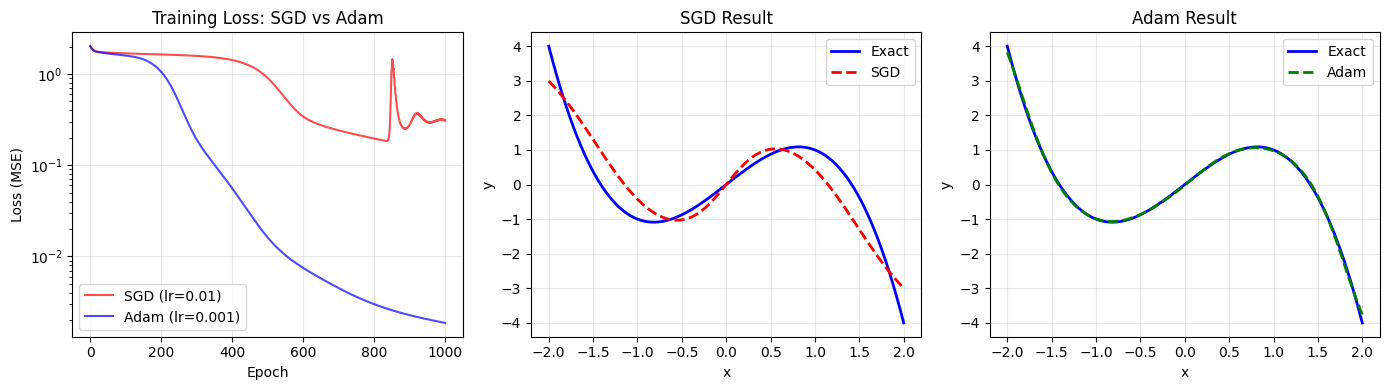


RESULTS SUMMARY
SGD  - Final Loss: 0.308979
Adam - Final Loss: 0.001871

Adam typically converges faster and to a better solution!
Plot saved as 'exercise2_results.png'


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

x_data = torch.linspace(-2,2,101).reshape(-1,1)
y_data = 2*x_data - x_data**3

class SimpleNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1= nn.Linear(1,10)
        self.layer2= nn.Linear(10,20)
        self.layer3= nn.Linear(20,10)
        self.layer4= nn.Linear(10,1)

        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self,x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = torch.tanh(self.layer3(x))
        x= self.layer4(x)
        return x

def train(model, optimizer, epochs=1000):
    loss_fn = nn.MSELoss()
    losses= []

    for epoch in range(epochs):
        prediction = model(x_data)
        loss = loss_fn(prediction, y_data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1)%200 == 0:
            print(f"Epocj {epoch+1}: Loss ={loss.item():.6f}")

    return losses

torch.manual_seed(42)
model_sgd = SimpleNetwork()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
losses_sgd = train(model_sgd, optimizer_sgd, epochs=1000)

torch.manual_seed(42)
model_adam = SimpleNetwork()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam = train(model_adam, optimizer_adam, epochs=1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Loss comparison
axes[0].plot(losses_sgd, 'r-', label='SGD (lr=0.01)', alpha=0.7)
axes[0].plot(losses_adam, 'b-', label='Adam (lr=0.001)', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training Loss: SGD vs Adam')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot 2: SGD predictions
with torch.no_grad():
    pred_sgd = model_sgd(x_data).numpy()
axes[1].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[1].plot(x_data.numpy(), pred_sgd, 'r--', linewidth=2, label='SGD')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('SGD Result')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Adam predictions
with torch.no_grad():
    pred_adam = model_adam(x_data).numpy()
axes[2].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[2].plot(x_data.numpy(), pred_adam, 'g--', linewidth=2, label='Adam')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Adam Result')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exercise2_results.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"SGD  - Final Loss: {losses_sgd[-1]:.6f}")
print(f"Adam - Final Loss: {losses_adam[-1]:.6f}")
print(f"\nAdam typically converges faster and to a better solution!")
print("Plot saved as 'exercise2_results.png'")

Data: 101 points, function y = 2x - x^3

Training with SGD (lr=0.01)
  Epoch 200: Loss = 1.637571
  Epoch 400: Loss = 1.423007
  Epoch 600: Loss = 0.342829
  Epoch 800: Loss = 0.196126
  Epoch 1000: Loss = 0.308979

Training with Adam (lr=0.001)
  Epoch 200: Loss = 1.063809
  Epoch 400: Loss = 0.056254
  Epoch 600: Loss = 0.007512
  Epoch 800: Loss = 0.003003
  Epoch 1000: Loss = 0.001871


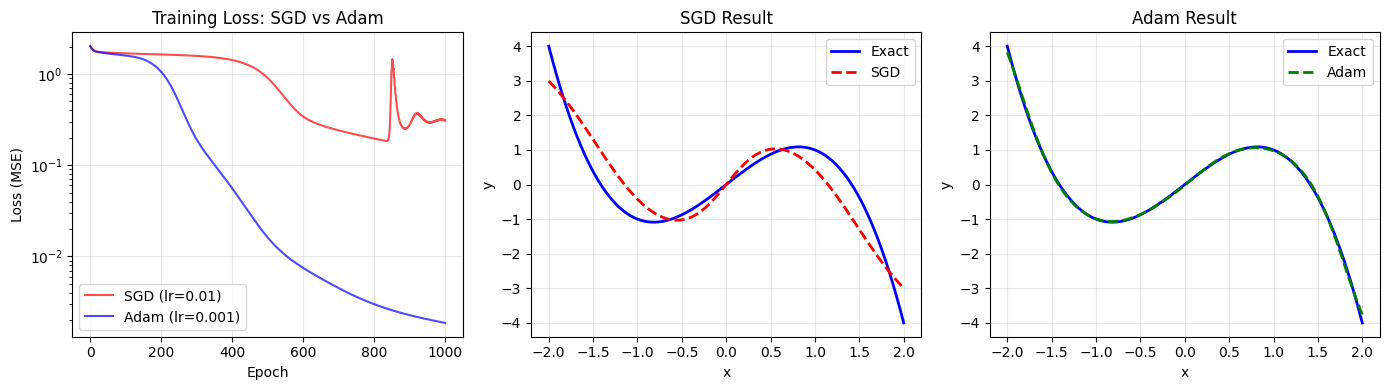


RESULTS SUMMARY
SGD  - Final Loss: 0.308979
Adam - Final Loss: 0.001871

Adam typically converges faster and to a better solution!
Plot saved as 'exercise2_results.png'


In [22]:
"""
Exercise 2: SGD vs Adam Optimizer Comparison
=============================================
Compare how SGD and Adam optimizers train on the same problem

Run: python exercise2_optimizers.py
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================
# Step 1: Create the training data
# ============================================
x_data = torch.linspace(-2, 2, 101).reshape(-1, 1)
y_data = 2 * x_data - x_data ** 3

print("Data: 101 points, function y = 2x - x^3\n")


# ============================================
# Step 2: Define the neural network
# ============================================
class SimpleNetwork(nn.Module):
    """4-layer network with Xavier initialization"""

    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 10)
        self.layer2 = nn.Linear(10, 20)
        self.layer3 = nn.Linear(20, 10)
        self.layer4 = nn.Linear(10, 1)

        # Use Xavier initialization for fair comparison
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = torch.tanh(self.layer3(x))
        x = self.layer4(x)
        return x


# ============================================
# Step 3: Training function
# ============================================
def train(model, optimizer, epochs=1000):
    """Train and return loss history"""
    loss_fn = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        prediction = model(x_data)
        loss = loss_fn(prediction, y_data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (epoch + 1) % 200 == 0:
            print(f"  Epoch {epoch+1}: Loss = {loss.item():.6f}")

    return losses


# ============================================
# Step 4: Train with SGD
# ============================================
print("="*50)
print("Training with SGD (lr=0.01)")
print("="*50)

# Set random seed for reproducibility
torch.manual_seed(42)
model_sgd = SimpleNetwork()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
losses_sgd = train(model_sgd, optimizer_sgd, epochs=1000)


# ============================================
# Step 5: Train with Adam
# ============================================
print("\n" + "="*50)
print("Training with Adam (lr=0.001)")
print("="*50)

# Reset seed for fair comparison
torch.manual_seed(42)
model_adam = SimpleNetwork()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam = train(model_adam, optimizer_adam, epochs=1000)


# ============================================
# Step 6: Plot results
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Loss comparison
axes[0].plot(losses_sgd, 'r-', label='SGD (lr=0.01)', alpha=0.7)
axes[0].plot(losses_adam, 'b-', label='Adam (lr=0.001)', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training Loss: SGD vs Adam')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot 2: SGD predictions
with torch.no_grad():
    pred_sgd = model_sgd(x_data).numpy()
axes[1].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[1].plot(x_data.numpy(), pred_sgd, 'r--', linewidth=2, label='SGD')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('SGD Result')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Adam predictions
with torch.no_grad():
    pred_adam = model_adam(x_data).numpy()
axes[2].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[2].plot(x_data.numpy(), pred_adam, 'g--', linewidth=2, label='Adam')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Adam Result')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exercise2_results.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"SGD  - Final Loss: {losses_sgd[-1]:.6f}")
print(f"Adam - Final Loss: {losses_adam[-1]:.6f}")
print(f"\nAdam typically converges faster and to a better solution!")
print("Plot saved as 'exercise2_results.png'")

In [28]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim

x_data = torch.linspace(-2,2,101).reshape(-1,1)
y_data = 2*x_data - x_data**3

class SimpleNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(1,10)
        self.layer2 = nn.Linear(10,20)
        self.layer3 = nn.Linear(20,10)
        self.layer4 = nn.Linear(10,1)

        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = torch.tanh(self.layer3(x))
        x= self.layer4(x)
        return x


def train(model,lr, optimizer, use_full_batch =True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses =[]

    for epoch in range(epochs):
        if use_full_batch:
            prediction = model(x_data)
            loss = loss_fn(prediction, y_data)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss.append(loss.item())

        else:
            #min batch : process one sample at a time
            eppoch_loss = 0
            for i in range(len(x_data)):
                x_sample = x_data[i:i+1]
                y_sample = y_data[iLi+1]

                pred= model(x_sample)
                loss = loss_fn(pred, y_sample)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            losses.append(epoch_loss/len(x_data))

        return losses

## Different learning rates

learning_rates = [0.1, 0.01, 0.001, 0.0001]
results_lr ={}

for lr in learning_rates:
    torch.manual_seed(42)
    model= SimpleNetwork()
    losses = train(model, lr=lr, epochs= 500)
    results_lr[lr] = losses
    print(f"lr=[lr]: final loss ={losses[-1]:.6f}")

print("\n" + "="*50)
print("EXPERIMENT 2: Different Number of Epochs")
print("="*50)

epoch_values = [100, 500, 1000, 2000]
results_epochs = {}

for epochs in epoch_values:
    torch.manual_seed(42)
    model = SimpleNetwork()
    losses = train(model, lr=0.001, epochs=epochs)
    results_epochs[epochs] = losses
    print(f"epochs={epochs}: Final loss = {losses[-1]:.6f}")


torch.manual_seed(42)
model_full = SimpleNetwork()
losses_full = train(model_full, lr=0.001, epochs=300, use_full_batch=True)
print(f"Full batch: Final loss ={losses_full[-1]:.6f}")

torch.manual_seed(42)
model_mini = SimpleNetwork()
losses_mini = train(model_mini, lr=0.001, epochs=300, use_full_batch=False)
print(f"Full batch: Final loss ={losses_full[-1]:.6f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Learning rate comparison
for lr, losses in results_lr.items():
    axes[0, 0].plot(losses, label=f'lr={lr}', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Effect of Learning Rate')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Epochs comparison
colors = ['red', 'orange', 'green', 'blue']
for (epochs, losses), color in zip(results_epochs.items(), colors):
    axes[0, 1].plot(losses, label=f'{epochs} epochs', color=color, alpha=0.7)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Effect of Number of Epochs')
axes[0, 1].legend()
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Full batch vs mini-batch
axes[1, 0].plot(losses_full, 'b-', label='Full Batch', alpha=0.7)
axes[1, 0].plot(losses_mini, 'r-', label='Mini-batch', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Full Batch vs Mini-batch')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Final prediction with best settings
torch.manual_seed(42)
model_best = SimpleNetwork()
train(model_best, lr=0.001, epochs=1000)

with torch.no_grad():
    pred_best = model_best(x_data).numpy()

axes[1, 1].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[1, 1].plot(x_data.numpy(), pred_best, 'r--', linewidth=2, label='Predicted')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')
axes[1, 1].set_title('Best Result (lr=0.001, epochs=1000)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exercise3_results.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("KEY OBSERVATIONS")
print("="*50)
print("1. Learning rate too high (0.1) -> training may diverge")
print("2. Learning rate too low (0.0001) -> very slow convergence")
print("3. Good learning rate (0.001) -> smooth, fast convergence")
print("4. More epochs -> lower loss (but diminishing returns)")
print("5. Full batch -> smoother loss curve")
print("6. Mini-batch -> noisier but sometimes faster")
print("\nPlot saved as 'exercise3_results.png'")

TypeError: train() got an unexpected keyword argument 'epochs'

Data: 101 points, function y = 2x - x^3

EXPERIMENT 1: Different Learning Rates
lr=0.1: Final loss = 0.006524
lr=0.01: Final loss = 0.000833
lr=0.001: Final loss = 0.016242
lr=0.0001: Final loss = 1.657902

EXPERIMENT 2: Different Number of Epochs
epochs=100: Final loss = 1.594341
epochs=500: Final loss = 0.016242
epochs=1000: Final loss = 0.001871
epochs=2000: Final loss = 0.000450

EXPERIMENT 3: Full Batch vs Mini-batch
Full batch: Final loss = 0.193722
Mini-batch: Final loss = 0.087409


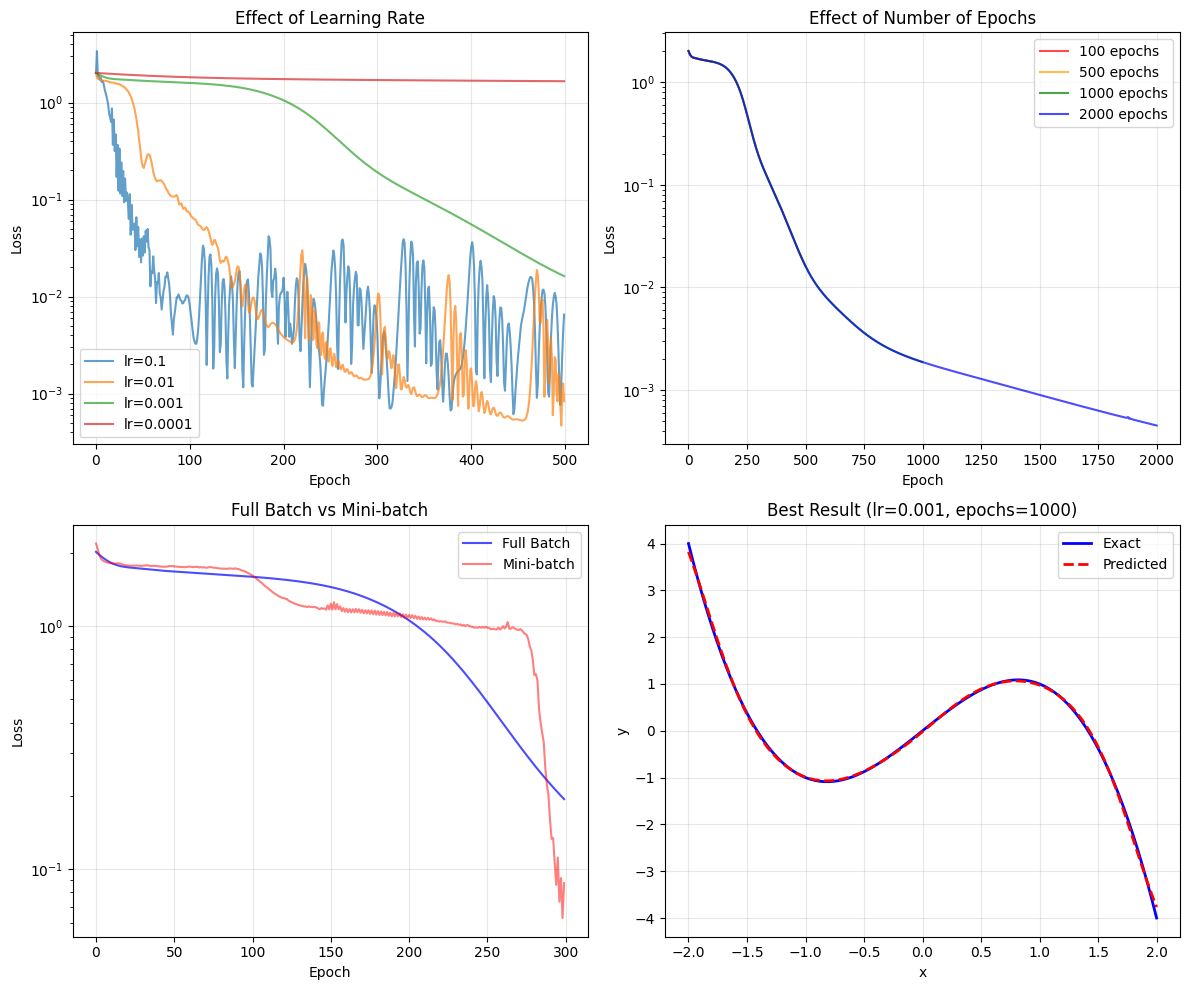


KEY OBSERVATIONS
1. Learning rate too high (0.1) -> training may diverge
2. Learning rate too low (0.0001) -> very slow convergence
3. Good learning rate (0.001) -> smooth, fast convergence
4. More epochs -> lower loss (but diminishing returns)
5. Full batch -> smoother loss curve
6. Mini-batch -> noisier but sometimes faster

Plot saved as 'exercise3_results.png'


In [29]:
"""
Exercise 3: Learning Rate and Epochs
=====================================
Experiment with different learning rates and number of epochs

Run: python exercise3_hyperparams.py
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================
# Step 1: Create the training data
# ============================================
x_data = torch.linspace(-2, 2, 101).reshape(-1, 1)
y_data = 2 * x_data - x_data ** 3

print("Data: 101 points, function y = 2x - x^3\n")


# ============================================
# Step 2: Define the neural network
# ============================================
class SimpleNetwork(nn.Module):
    """4-layer network with Xavier initialization"""

    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 10)
        self.layer2 = nn.Linear(10, 20)
        self.layer3 = nn.Linear(20, 10)
        self.layer4 = nn.Linear(10, 1)

        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = torch.tanh(self.layer3(x))
        x = self.layer4(x)
        return x


# ============================================
# Step 3: Training function
# ============================================
def train(model, lr, epochs, use_full_batch=True):
    """
    Train model with given learning rate and epochs

    use_full_batch=True: Process all data at once (smoother)
    use_full_batch=False: Process one sample at a time (noisier)
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        if use_full_batch:
            # Full batch: use all data at once
            prediction = model(x_data)
            loss = loss_fn(prediction, y_data)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        else:
            # Mini-batch (size 1): process one sample at a time
            epoch_loss = 0
            for i in range(len(x_data)):
                x_sample = x_data[i:i+1]
                y_sample = y_data[i:i+1]

                pred = model(x_sample)
                loss = loss_fn(pred, y_sample)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            losses.append(epoch_loss / len(x_data))

    return losses


# ============================================
# Step 4: Experiment with different learning rates
# ============================================
print("="*50)
print("EXPERIMENT 1: Different Learning Rates")
print("="*50)

learning_rates = [0.1, 0.01, 0.001, 0.0001]
results_lr = {}

for lr in learning_rates:
    torch.manual_seed(42)
    model = SimpleNetwork()
    losses = train(model, lr=lr, epochs=500)
    results_lr[lr] = losses
    print(f"lr={lr}: Final loss = {losses[-1]:.6f}")


# ============================================
# Step 5: Experiment with different epochs
# ============================================
print("\n" + "="*50)
print("EXPERIMENT 2: Different Number of Epochs")
print("="*50)

epoch_values = [100, 500, 1000, 2000]
results_epochs = {}

for epochs in epoch_values:
    torch.manual_seed(42)
    model = SimpleNetwork()
    losses = train(model, lr=0.001, epochs=epochs)
    results_epochs[epochs] = losses
    print(f"epochs={epochs}: Final loss = {losses[-1]:.6f}")


# ============================================
# Step 6: Compare full batch vs mini-batch
# ============================================
print("\n" + "="*50)
print("EXPERIMENT 3: Full Batch vs Mini-batch")
print("="*50)

torch.manual_seed(42)
model_full = SimpleNetwork()
losses_full = train(model_full, lr=0.001, epochs=300, use_full_batch=True)
print(f"Full batch: Final loss = {losses_full[-1]:.6f}")

torch.manual_seed(42)
model_mini = SimpleNetwork()
losses_mini = train(model_mini, lr=0.001, epochs=300, use_full_batch=False)
print(f"Mini-batch: Final loss = {losses_mini[-1]:.6f}")


# ============================================
# Step 7: Plot all results
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Learning rate comparison
for lr, losses in results_lr.items():
    axes[0, 0].plot(losses, label=f'lr={lr}', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Effect of Learning Rate')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Epochs comparison
colors = ['red', 'orange', 'green', 'blue']
for (epochs, losses), color in zip(results_epochs.items(), colors):
    axes[0, 1].plot(losses, label=f'{epochs} epochs', color=color, alpha=0.7)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Effect of Number of Epochs')
axes[0, 1].legend()
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Full batch vs mini-batch
axes[1, 0].plot(losses_full, 'b-', label='Full Batch', alpha=0.7)
axes[1, 0].plot(losses_mini, 'r-', label='Mini-batch', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Full Batch vs Mini-batch')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Final prediction with best settings
torch.manual_seed(42)
model_best = SimpleNetwork()
train(model_best, lr=0.001, epochs=1000)

with torch.no_grad():
    pred_best = model_best(x_data).numpy()

axes[1, 1].plot(x_data.numpy(), y_data.numpy(), 'b-', linewidth=2, label='Exact')
axes[1, 1].plot(x_data.numpy(), pred_best, 'r--', linewidth=2, label='Predicted')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')
axes[1, 1].set_title('Best Result (lr=0.001, epochs=1000)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exercise3_results.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("KEY OBSERVATIONS")
print("="*50)
print("1. Learning rate too high (0.1) -> training may diverge")
print("2. Learning rate too low (0.0001) -> very slow convergence")
print("3. Good learning rate (0.001) -> smooth, fast convergence")
print("4. More epochs -> lower loss (but diminishing returns)")
print("5. Full batch -> smoother loss curve")
print("6. Mini-batch -> noisier but sometimes faster")
print("\nPlot saved as 'exercise3_results.png'")